In [1]:
#!pip install numpy pandas matplotlib seaborn

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline
# Replace 'data.csv' with the EXACT name of the file you moved into Codespaces
data = pd.read_csv('dirty_cafe_sales.csv') 

# This cleans the column names to prevent "KeyError"
data.columns = data.columns.str.strip()


In [3]:
data.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 4.1 MB


In [4]:
data.columns = (
    data.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
)


cols = ["total_spent", "quantity", "price_per_unit"]
data[cols] = data[cols].apply(pd.to_numeric, errors="coerce")

In [5]:
data['item'] = data['item'].astype('category')
data['location'] = data['location'].astype('category')
data['payment_method'] = data['payment_method'].astype('category')


# get rid of 'ERROR' and 'UNKNOWN' values

cols = ['item', 'payment_method', 'location']
data[cols] = data[cols].apply(lambda col: col.replace(['ERROR', 'UNKNOWN'], np.nan))

data['transaction_date'] = pd.to_datetime(
    data['transaction_date'],
    errors='coerce'
)
data.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  str           
 1   item              9031 non-null   category      
 2   quantity          9521 non-null   float64       
 3   price_per_unit    9467 non-null   float64       
 4   total_spent       9498 non-null   float64       
 5   payment_method    6822 non-null   category      
 6   location          6039 non-null   category      
 7   transaction_date  9540 non-null   datetime64[us]
dtypes: category(3), datetime64[us](1), float64(3), str(1)
memory usage: 929.5 KB


In [6]:
prices = {
    "Coffee": 2,
    "Tea": 1.5,
    "Sandwich": 4,
    "Salad": 5,
    "Cake": 3,
    "Cookie": 1,
    "Smoothie": 4,
    "Juice": 3
}

price_to_items = {}
for item, price in prices.items():
    price_to_items.setdefault(price, []).append(item)

In [7]:
# filling in price_per_unit using total_spent / quantity
missing_prices = (
    data["price_per_unit"].isnull()
    & data["total_spent"].notnull()
    & data["quantity"].notnull()
    & (data["quantity"] != 0)
)

data.loc[missing_prices, "price_per_unit"] = (
    data.loc[missing_prices, "total_spent"] / data.loc[missing_prices, "quantity"]
)

In [8]:
# filling in price_per_unit using item
mask = data["price_per_unit"].isnull() & data["item"].isin(prices)
data.loc[mask, "price_per_unit"] = data.loc[mask, "item"].map(prices)

In [9]:
# fill in total_spent using quantity * price_per_unit
mask = (
    data["total_spent"].isnull()
    & data["price_per_unit"].notnull()
    & data["quantity"].notnull()
)

data.loc[mask, "total_spent"] = (
    data.loc[mask, "price_per_unit"] * data.loc[mask, "quantity"]
)

In [10]:
# fill in quantity using total_spent / price_per_unit

mask = (
    data["quantity"].isnull()
    & data["total_spent"].notnull()
    & data["price_per_unit"].notnull()
    & (data["price_per_unit"] != 0)
)

data.loc[mask, "quantity"] = (
    data.loc[mask, "total_spent"] / data.loc[mask, "price_per_unit"]
)

In [11]:
"""
fill in item using price_per_unit. since some items have same prices as other items,
only fill in item for items with a unique price.
They are Cookie, Tea, Coffee and Salad
"""
unique_price_map = {
    price: items[0]
    for price, items in price_to_items.items()
    if len(items) == 1
}

mask = data["item"].isnull() & data["price_per_unit"].isin(unique_price_map)
data.loc[mask, "item"] = data.loc[mask, "price_per_unit"].map(unique_price_map)

In [12]:
data.query("quantity.isnull() or price_per_unit.isnull() or total_spent.isnull()").sample(5)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
2289,TXN_7524977,NaN,4.0,NaN,NaN,NaN,NaN,2023-12-09
2796,TXN_9188692,Cake,NaN,3.0,NaN,Credit Card,NaN,2023-12-01
8021,TXN_2428781,Salad,NaN,5.0,NaN,NaN,In-store,2023-05-09
8465,TXN_9669616,Coffee,NaN,2.0,NaN,NaN,NaN,2023-06-03
236,TXN_8562645,Salad,NaN,5.0,NaN,NaN,In-store,2023-05-18


In [13]:
data.isnull().sum()

transaction_id         0
item                 480
quantity              23
price_per_unit         6
total_spent           23
payment_method      3178
location            3961
transaction_date     460
dtype: int64

In [14]:
data['day_of_week'] = data['transaction_date'].dt.day_name()
data['month'] = data['transaction_date'].dt.month_name()

earliest_date = data['transaction_date'].min()
latest_date = data['transaction_date'].max()
print("Earliest date is ", earliest_date)
print("Latest date is ", latest_date)
data

Earliest date is  2023-01-01 00:00:00
Latest date is  2023-12-31 00:00:00


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,day_of_week,month
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,Friday,September
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,Tuesday,May
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,Wednesday,July
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27,Thursday,April
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,Sunday,June
...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30,Wednesday,August
9996,TXN_9659401,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-06-02,Friday,June
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02,Thursday,March
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02,Saturday,December


In [15]:
data.columns = data.columns.str.strip()
# Check if price_per_unit is actually a number
data['price_per_unit'] = pd.to_numeric(data['price_per_unit'], errors='coerce')

# Drop any rows that are now empty so the graph doesn't look "expanded" or broken
data = data.dropna(subset=['price_per_unit'])

data['item'] = data['item'].str.strip().str.upper()
data = data[~data['item'].isin(['ERROR', 'UNKNOWN'])]

data['payment_method'] = data['payment_method'].str.strip().str.upper()
data = data[~data['payment_method'].isin(['ERROR', 'UNKNOWN'])]

data['location'] = data['location'].str.strip().str.upper()
data = data[~data['location'].isin(['ERROR', 'UNKNOWN'])]




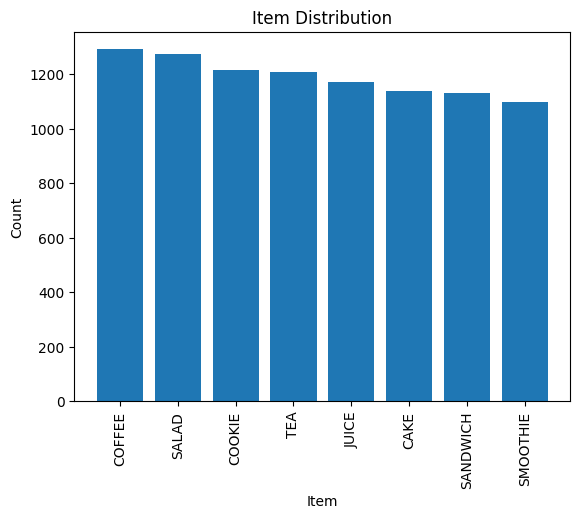

In [16]:
item_counts = data['item'].value_counts()

plt.figure()
plt.bar(item_counts.index, item_counts.values)

plt.xticks(rotation=90)
plt.xlabel("Item")
plt.ylabel("Count")
plt.title("Item Distribution")
plt.show()


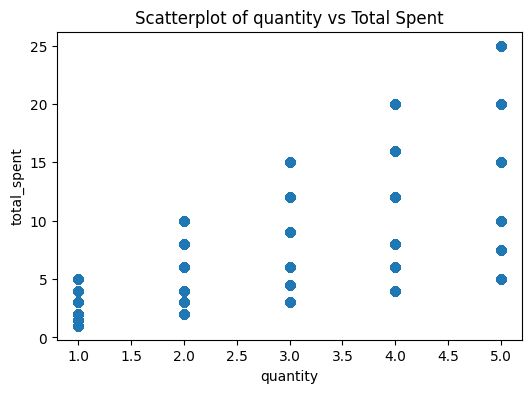

In [17]:
#6.3.1  Quantity vs Total Spent (scatterplot) (Numerical vs Numerical)


plt.figure(figsize=(6,4))
plt.scatter(data['quantity'], data['total_spent'])
plt.xlabel('quantity')
plt.ylabel('total_spent')
plt.title('Scatterplot of quantity vs Total Spent')
plt.show()


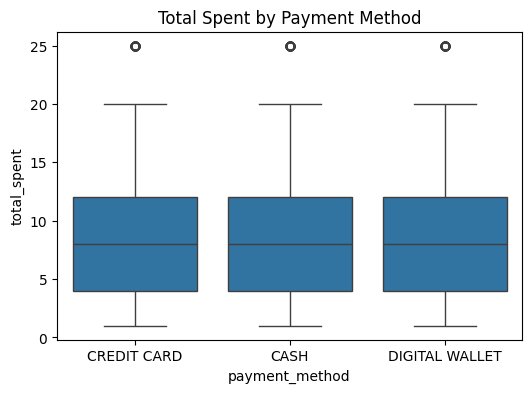

In [18]:
#6.3.2 Payment Method vs Total Spent (side-by-side boxplot) (Categorical vs Numerical)


plt.figure(figsize=(6,4))
sns.boxplot(x='payment_method', y='total_spent', data=data)
plt.title('Total Spent by Payment Method')
plt.show()

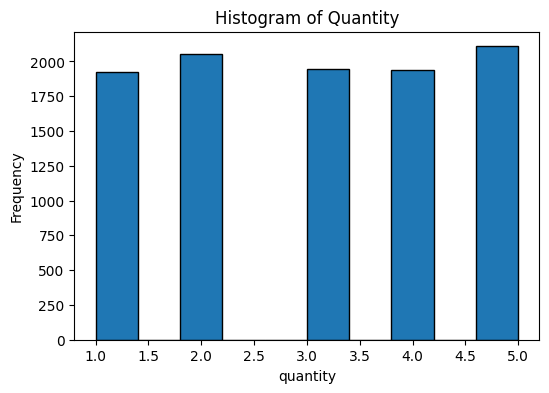

In [19]:
#6.2.1

plt.figure(figsize=(6,4))
plt.hist(data['quantity'], bins=10, edgecolor='black') #plt.hist is automatic function. Separate into 10 lenght (bin=10)
plt.xlabel('quantity')
plt.ylabel('Frequency') #Frequency represents the number of transactions within each quantity interval.
plt.title('Histogram of Quantity')
plt.show()

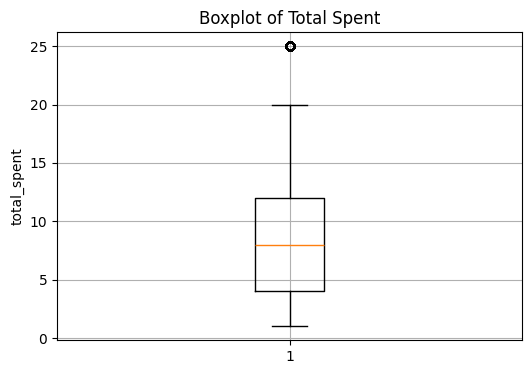

In [20]:
#6.2.2

plt.figure(figsize=(6,4))
plt.boxplot(data['total_spent'].dropna())
plt.ylabel('total_spent')
plt.title('Boxplot of Total Spent')
plt.grid(True)
plt.show()

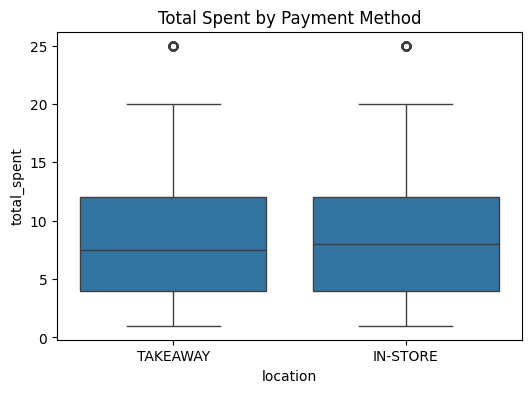

In [21]:
#6.3.2 Payment Method vs Total Spent (side-by-side boxplot) (Categorical vs Numerical)

plt.figure(figsize=(6,4))
sns.boxplot(x='location', y='total_spent', data=data)
plt.title('Total Spent by Payment Method')
plt.show()

In [22]:
data.groupby('payment_method')['location'].describe()

,count,unique,top,freq
payment_method,,,,
CASH,1366,2,IN-STORE,702
CREDIT CARD,1350,2,IN-STORE,681
DIGITAL WALLET,1438,2,TAKEAWAY,744


In [23]:
counts = data['item'].value_counts()
percent = data['item'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count': counts,
    'Percentage': percent
})

summary

,Count,Percentage
item,,
COFFEE,1291,13.560924
SALAD,1272,13.361345
COOKIE,1213,12.741597
TEA,1207,12.678571
JUICE,1171,12.300420
CAKE,1139,11.964286
SANDWICH,1131,11.880252
SMOOTHIE,1096,11.512605


In [24]:
mean_val = data['price_per_unit'].mean()
median_val = data['price_per_unit'].median()
q1 = data['price_per_unit'].quantile(0.25)
q3 = data['price_per_unit'].quantile(0.75)
iqr = q3 - q1

print("Mean:", mean_val)
print("Median:", median_val)
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)


Mean: 2.947018210926556
Median: 3.0
Q1: 2.0
Q3: 4.0
IQR: 2.0


In [25]:
print(data['item'].unique())


['COFFEE' 'CAKE' 'COOKIE' 'SALAD' 'SMOOTHIE' nan 'SANDWICH' 'TEA' 'JUICE']
